#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 6: Fashion MNIST  </center>

En esta actividad se diseñará y entrenará una arquitectura para clasificar las imágenes del dataset *Fashion MNIST*. 

## Objetivos

 - Adquirir experiencia práctica en la implementación de redes neuronales con la biblioteca *keras*
 - Evaluar la influencia que tienen en el entrenamiento de una *red profunda* la inclusión de técnicas como *Batch Normalization* o *Dropout* en la arquitectura de la red.
 - Evaluar el impacto de la *inicialización* de los pesos en el entrenamiento de una *red profunda*.
 - Diseñar, entrenar y evaluar arquitecturas para clasificar imágenes.  


# OBJS Resumidos
- Usar keras
- Efecto de *Batch Normalization* y *Dropout*
- Probar *inicialización* de los pesos en el entrenamiento
- Clasificar imagenes!

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2026/blob/main/talleres/taller6_Fashion-MNIST.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

In [1]:
from comet_ml import Experiment
import tensorflow as tf
from tensorflow import keras
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
I0000 00:00:1780838855.807799    8083 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
*!pip install paquete_faltante*

### Parte 1 - Levantar los datos

Se trabajará con el conjunto de datos *Fashion MNIST* disponible en [*Keras*](https://keras.io/api/datasets/fashion_mnist/). Levantar los datos y separar, de los datos disponibles para entrenamiento, un subconjunto de 10000 muestras para validación. 

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid = X_train_full[:10000].astype("float32") / 255.0
X_train = X_train_full[10000:].astype("float32") / 255.0

y_valid = y_train_full[:10000]
y_train = y_train_full[10000:]

X_test = X_test.astype("float32") / 255.0

### Parte 2  - Exploración de datos

Como es habitual, una buena práctica es explorar los datos para familiarizarse con el problema. 

Conteste a las siguientes preguntas:        
    - ¿Cuántas imágenes hay disponibles? ¿De qué tamaño son?       
    - ¿Cuál es el tipo de dato? ¿Es adecuado?         
Muestre las primeras $n$ imágenes del dataset con $n=25$ o un $n$ que le permita ver ejemplos de todas las clases.

Entrenamiento: X=(50000, 28, 28), y=(50000,)
Validación:    X=(10000, 28, 28), y=(10000,)
Test:          X=(10000, 28, 28), y=(10000,)

Tipo de las imágenes: float32
Tipo de las etiquetas: uint8
Rango de los píxeles: [0.0, 1.0]
Clases disponibles: [0 1 2 3 4 5 6 7 8 9]


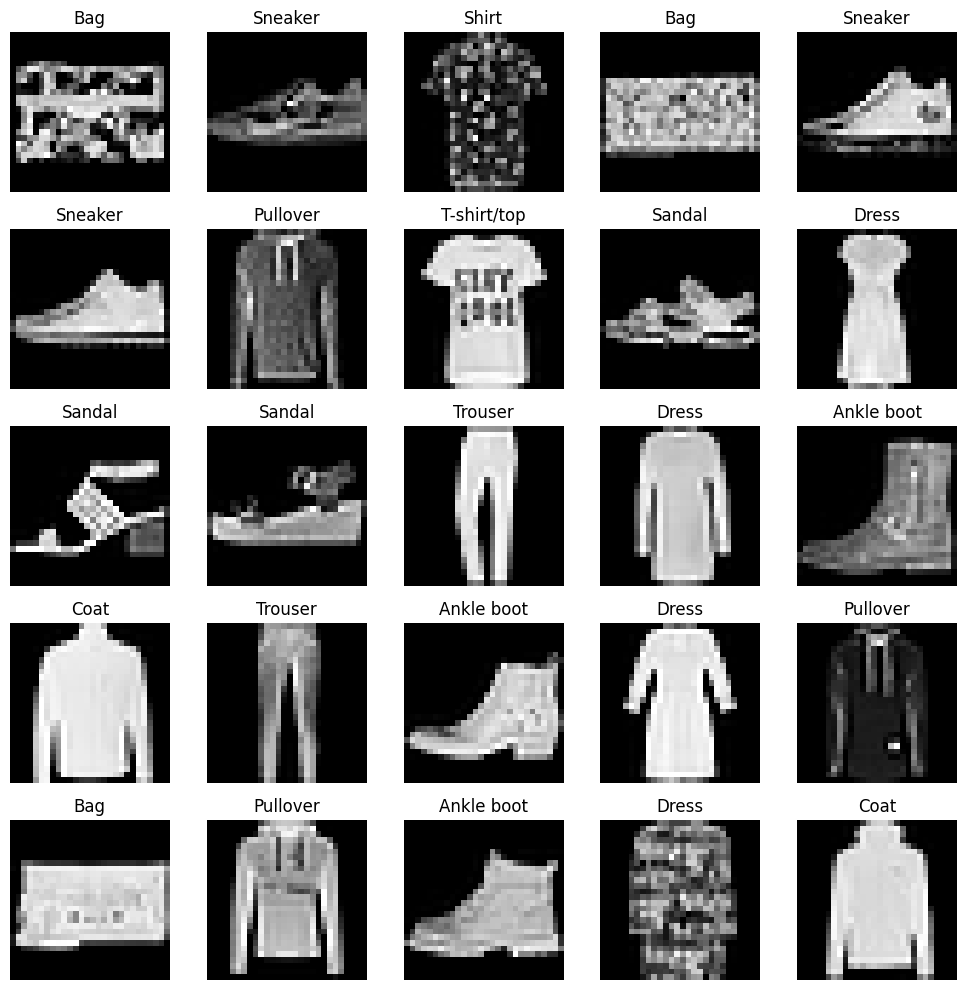

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print(f"Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Validación:    X={X_valid.shape}, y={y_valid.shape}")
print(f"Test:          X={X_test.shape}, y={y_test.shape}")
print()
print(f"Tipo de las imágenes: {X_train.dtype}")
print(f"Tipo de las etiquetas: {y_train.dtype}")
print(f"Rango de los píxeles: [{X_train.min()}, {X_train.max()}]")
print(f"Clases disponibles: {np.unique(y_train)}")

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for index, ax in enumerate(axes.flat):
    ax.imshow(X_train[index], cmap="gray")
    ax.set_title(class_names[y_train[index]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Exploracion de balance de clases y ejemplos

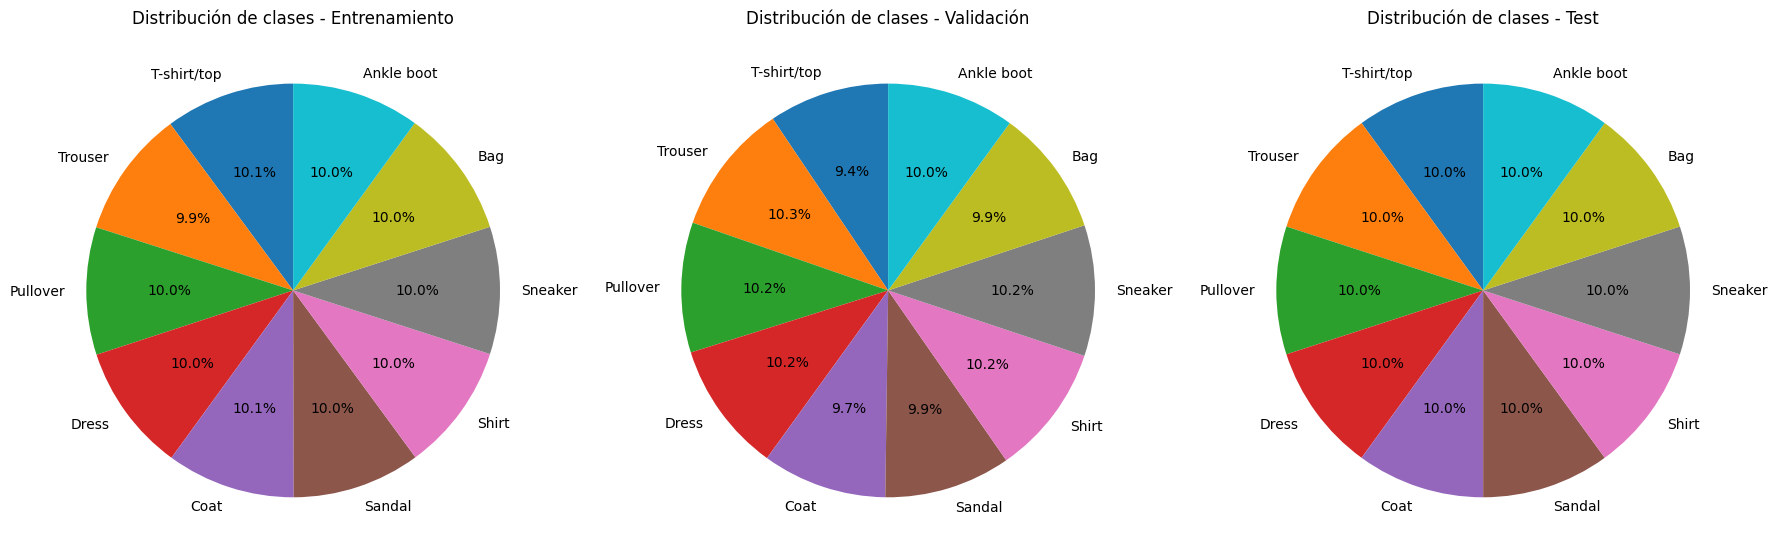

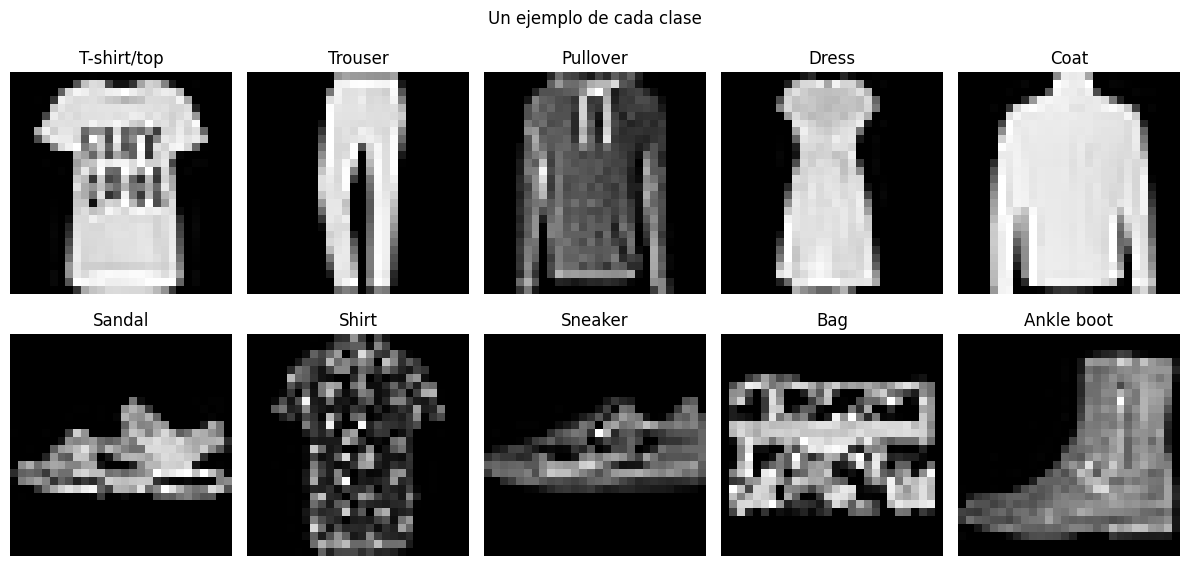

In [4]:
datasets = {
    "Entrenamiento": y_train,
    "Validación": y_valid,
    "Test": y_test,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (dataset_name, labels) in zip(axes, datasets.items()):
    class_counts = np.bincount(labels, minlength=len(class_names))
    ax.pie(
        class_counts,
        labels=class_names,
        autopct="%1.1f%%",
        startangle=90,
    )
    ax.set_title(f"Distribución de clases - {dataset_name}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for class_index, ax in enumerate(axes.flat):
    example_index = np.flatnonzero(y_train == class_index)[0]
    ax.imshow(X_train[example_index], cmap="gray")
    ax.set_title(class_names[class_index])
    ax.axis("off")

plt.suptitle("Un ejemplo de cada clase")
plt.tight_layout()
plt.show()

#### Respuestas

- Luego de separar el conjunto original de entrenamiento, hay **50.000 imágenes de entrenamiento**, **10.000 de validación** y **10.000 de test**.
- Cada imagen tiene un tamaño de **28 × 28 píxeles** y está representada en escala de grises.
- Las imágenes tienen tipo `float32`, adecuado para trabajar con TensorFlow, y sus píxeles fueron normalizados al intervalo `[0, 1]`.
- Las etiquetas son números enteros entre `0` y `9`. Cada número representa una de las diez clases de prendas de Fashion MNIST.

### Parte 3 - Un primer modelo

Construya una red neuronal totalmente conectada de 20 capas y 100 neuronas por capa. Para ello se sugiere completar la implementación de la función `fully_connected_model`. Utilice *relu* como función de activación y *sgd* como optimizador.  Indique cuántos parámetros tiene la red.

In [5]:
def fully_connected_model(input_shape, n_hiddens, n_neurons, activation='relu', 
                        optimizer='sgd', learning_rate = 1e-3):
    
    '''
    Entrada:
        input_shape: [M,N]
        n_hiddens: número de capas ocultas
        n_neurons: número de neuronas en cada capa oculta
        activation: función de activación de las neuronas. Por defecto 'relu'.
        optimizer: método de optimización. Por defecto 'sgd'.
        learning_rate: tasa de aprendizaje del optimizador. Por defecto 1e-3.
    Salida:
        model: modelo generado
    '''

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=input_shape))
    model.add(keras.layers.Flatten())

    for _ in range(n_hiddens):
        model.add(keras.layers.Dense(n_neurons, activation=activation))

    model.add(keras.layers.Dense(10, activation="softmax"))

    optimizer_instance = keras.optimizers.get(optimizer)
    optimizer_instance.learning_rate = learning_rate

    model.compile(
        optimizer=optimizer_instance,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = fully_connected_model(
    input_shape=X_train.shape[1:],
    n_hiddens=20,
    n_neurons=100,
    activation="relu",
    optimizer="sgd",
    learning_rate=1e-3,
)

model.summary()

W0000 00:00:1780838864.318789    8083 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,410 (1.04 MB)

 Trainable params: 271,410 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

### Parte 4 -  Un primer entrenamiento

Entrene el modelo generado en la parte anterior durante 10 épocas para los siguientes valores de *learning rate*: [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]. Muestre los desempeños en los conjuntos de entrenamiento y validación. 

### Parte 5: - Cambio de Inicialización 

**5a)** Repita el experimento pero cambiando el método de inicialización de los pesos. En vez de utilizar la inicialización por defecto, utilice 'he_normal'. Comente como cambian los resultados.

**5b) (opcional):** Probar otras formas de inicialización. Por ejemplo, ¿Qué pasa si se utiliza 'random_normal'?

### Parte 6 - Batch Normalization

Modifique la implementación de la función *fully_connected_model* para que admita la posibilidad de agregar capas de *batch normalization*. En caso de utilizar *batch normalization* coloque dichas capas luego de las capas densas y antes de las activaciones, tal como fue propuesto en el [paper original](https://arxiv.org/pdf/1502.03167.pdf). 

**6a)** ¿Cuántos parámetros tiene el modelo con *batch normalization*? ¿Qué son y para que se usan los *Non-trainable-parameters*?

**6b)** Repita el experimento de la **parte 4** pero ahora utilizando el modelo con *batch normalization*. Para este experimento vuelva a la inicialización de los pesos por defecto ('glorot_uniform').

### Parte 7 -  Optimizador

**Parte 7a)** De ser necesario, modifique la implementación de la función `fully_connected_model()` para que permita optimizar utilizando el método *adam*. Repita el experimento de la **parte 4** pero modificando solamente el optimizador. Comente los cambios que observa.

**Parte 7b)** ¿Cambian los resultados del entrenamiento si en la parte anterior además de cambiar el optimizador se agrega *batch normalization* ?

### Parte 8  -  Red Neuronal Convolucional

**8a)** Escribir una función similar a la de la **parte 3** pero que construya una red neuronal convolucional con la siguiente arquitectura:
    
N * [Conv2D --> Conv2D --> Pool2D] → Flatten → Dense → Dense. 

donde *N* representa la cantidad de bloques [Conv2D --> Conv2D --> Pool2D] a utilizar. 

**8b)** Entrenar una realización de la red. Por ejemplo, utilizar:
- N=2
- 64 filtros de convolución de tamaño 3 en la primera capa del bloque
- 32 filtros de convolución de tamaño 3 en la segunda capa del bloque
- 128 neuronas en la primera capa densa 

**8c)** ¿Cuántos parámetros tiene el modelo?

### Parte 9 - Entrenar la mejor arquitectura posible

En esta parte el objetivo será entrenar el mejor clasificador posible para *Fashion MNIST*. La única restricción es que el modelo de arquitectura tendrá que ser como el de la **parte 3** o como el de la **parte 8**. En ambos casos se podrán evaluar las siguientes variaciones:     
    - Número de capas y neuronas por capa en el modelo de la **parte3**.     
    - Número de bloques, cantidad de filtros de bloque y tamaño de los filtros en el caso del modelo de la **parte 8**.              
    - Distintas funciones de activación y métodos de inicialización de pesos.     
    - Agregado de *Batch Normalization* y/o *Dropout*.    
    - Distintos métodos de optimización y sus parámetros.     

Para entrenar los modelos se recomienda la utilización de alguno de los [callbacks](https://keras.io/callbacks/) disponibles en *keras*. Por ejemplo: *early stopping* y *model checkpoint*.